In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# This is required for SHAP plots to render inside Jupyter
shap.initjs()

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [2]:
# Load the saved XGBoost model and test data
xgb_model = joblib.load('../models/xgb_model.pkl')

X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print(f"Model loaded successfully")
print(f"Test set shape: {X_test.shape}")

Model loaded successfully
Test set shape: (61503, 58)


In [3]:
# TreeExplainer is optimized specifically for tree-based models
# like XGBoost, LightGBM, RandomForest
# It is much faster than the generic KernelExplainer

explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the entire test set
# This may take 1-2 minutes
print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP values calculated successfully")

Calculating SHAP values...
SHAP values shape: (61503, 58)
SHAP values calculated successfully


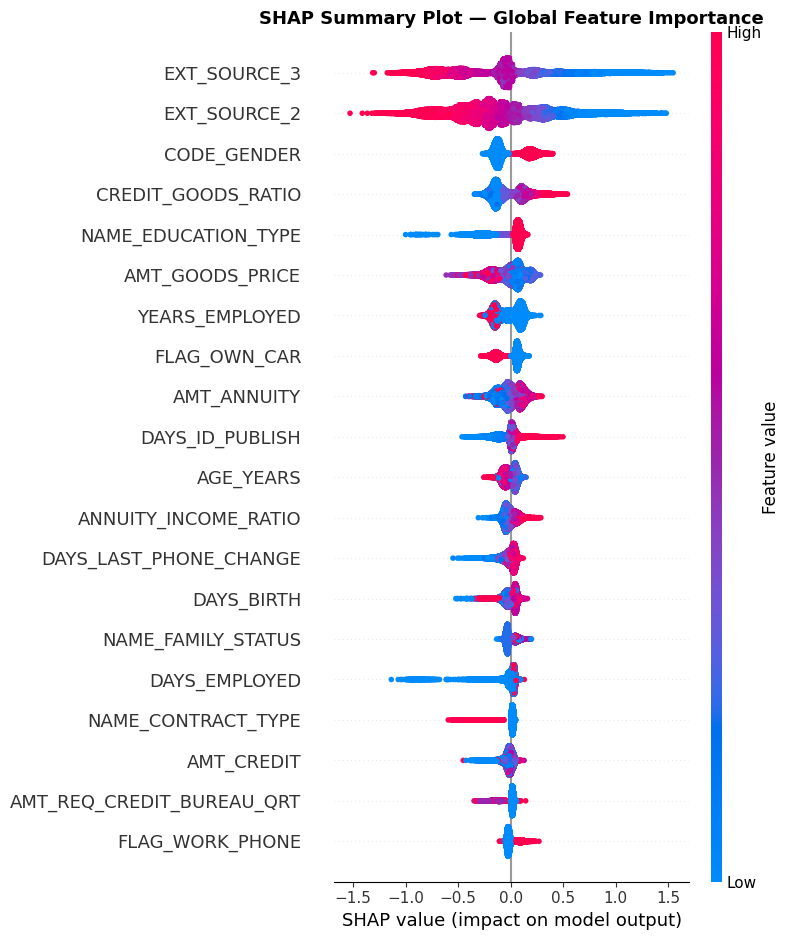

Saved: shap_summary_plot.png


In [4]:
# This is the most important SHAP plot
# It shows which features matter most across ALL predictions
# Red = high feature value, Blue = low feature value

plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot — Global Feature Importance",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_summary_plot.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved: shap_summary_plot.png")

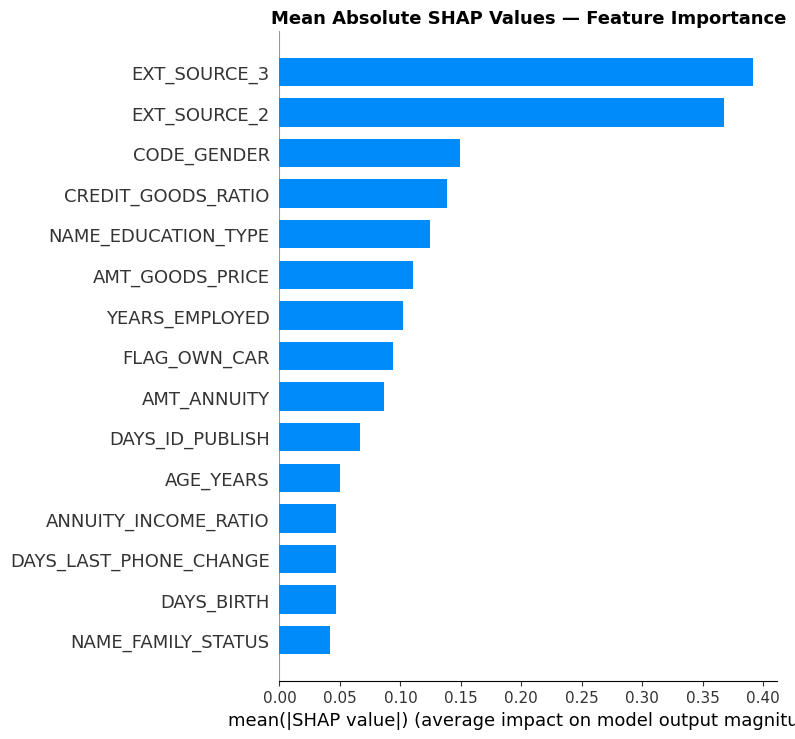

Saved: shap_bar_plot.png


In [5]:
# Simpler version — just shows average impact of each feature
# Good for presentations and non-technical stakeholders

plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title("Mean Absolute SHAP Values — Feature Importance",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_bar_plot.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved: shap_bar_plot.png")

Top feature by SHAP: EXT_SOURCE_3


<Figure size 800x500 with 0 Axes>

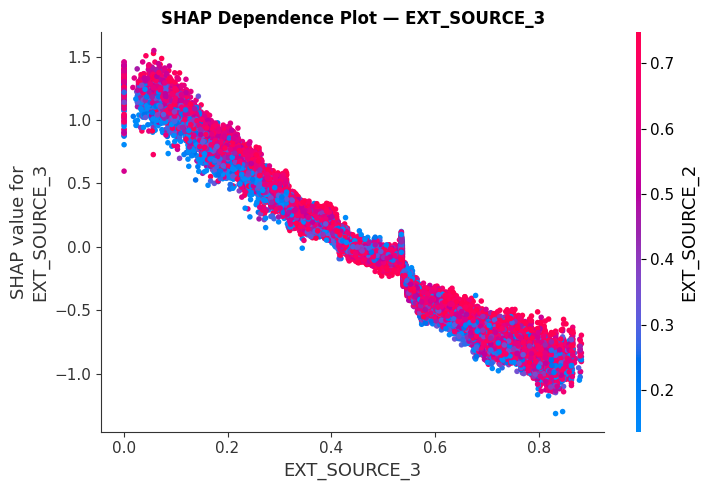

In [6]:
# Shows how a single feature affects predictions
# Also reveals interaction effects with other features
# We use EXT_SOURCE_3 as it is typically the top feature

top_feature = shap_values.mean(axis=0)
top_feature_name = X_test.columns[np.argmax(np.abs(shap_values).mean(axis=0))]

print(f"Top feature by SHAP: {top_feature_name}")

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_feature_name,
    shap_values,
    X_test,
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name}",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_dependence_plot.png',
            bbox_inches='tight', dpi=150)
plt.show()

Explaining prediction for applicant at index: 9
Actual outcome: Defaulted


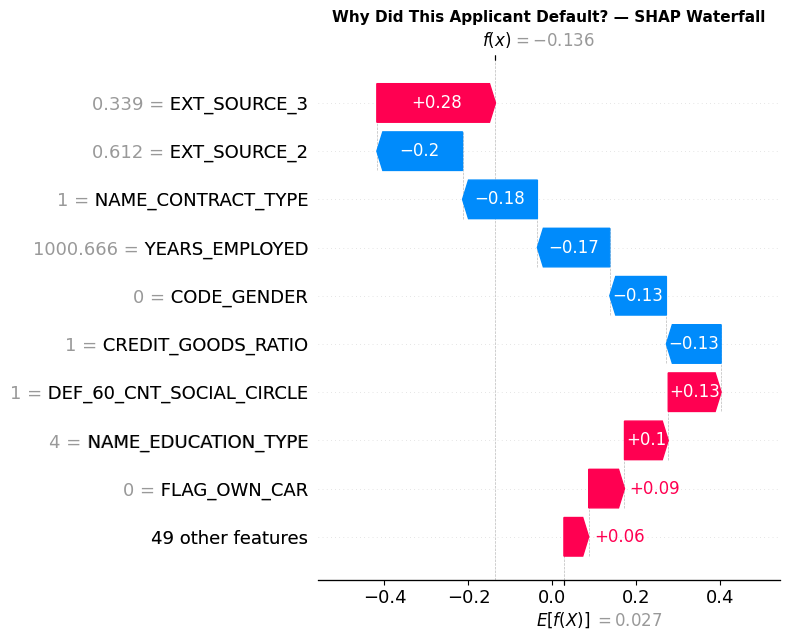

In [7]:
# This is the most powerful feature for interviews
# It explains WHY the model made a specific decision
# for one individual applicant

# Pick a defaulter from test set
defaulter_idx = y_test[y_test == 1].index[0]
position      = X_test.index.get_loc(defaulter_idx)

print(f"Explaining prediction for applicant at index: {defaulter_idx}")
print(f"Actual outcome: {'Defaulted' if y_test[defaulter_idx] == 1 else 'Repaid'}")

# Waterfall plot for this individual
shap_explanation = shap.Explanation(
    values         = shap_values[position],
    base_values    = explainer.expected_value,
    data           = X_test.iloc[position],
    feature_names  = X_test.columns.tolist()
)

plt.figure()
shap.plots.waterfall(shap_explanation, show=False)
plt.title("Why Did This Applicant Default? — SHAP Waterfall",
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_waterfall_defaulter.png',
            bbox_inches='tight', dpi=150)
plt.show()

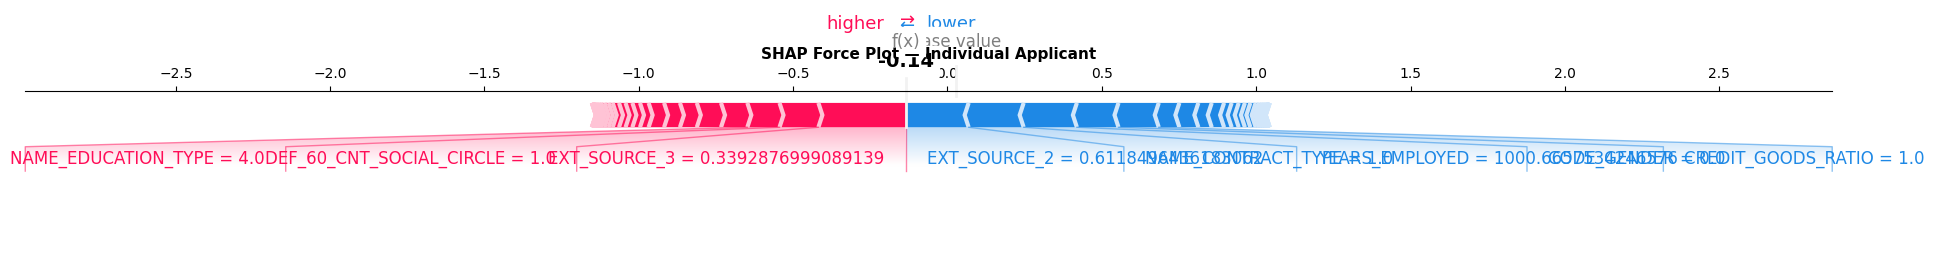

In [8]:
# Force plot shows the same info as waterfall
# but in a horizontal format — great for Streamlit app later

force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[position],
    X_test.iloc[position],
    feature_names=X_test.columns.tolist(),
    matplotlib=True,
    show=False
)
plt.title("SHAP Force Plot — Individual Applicant",
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_force_plot.png',
            bbox_inches='tight', dpi=150)
plt.show()

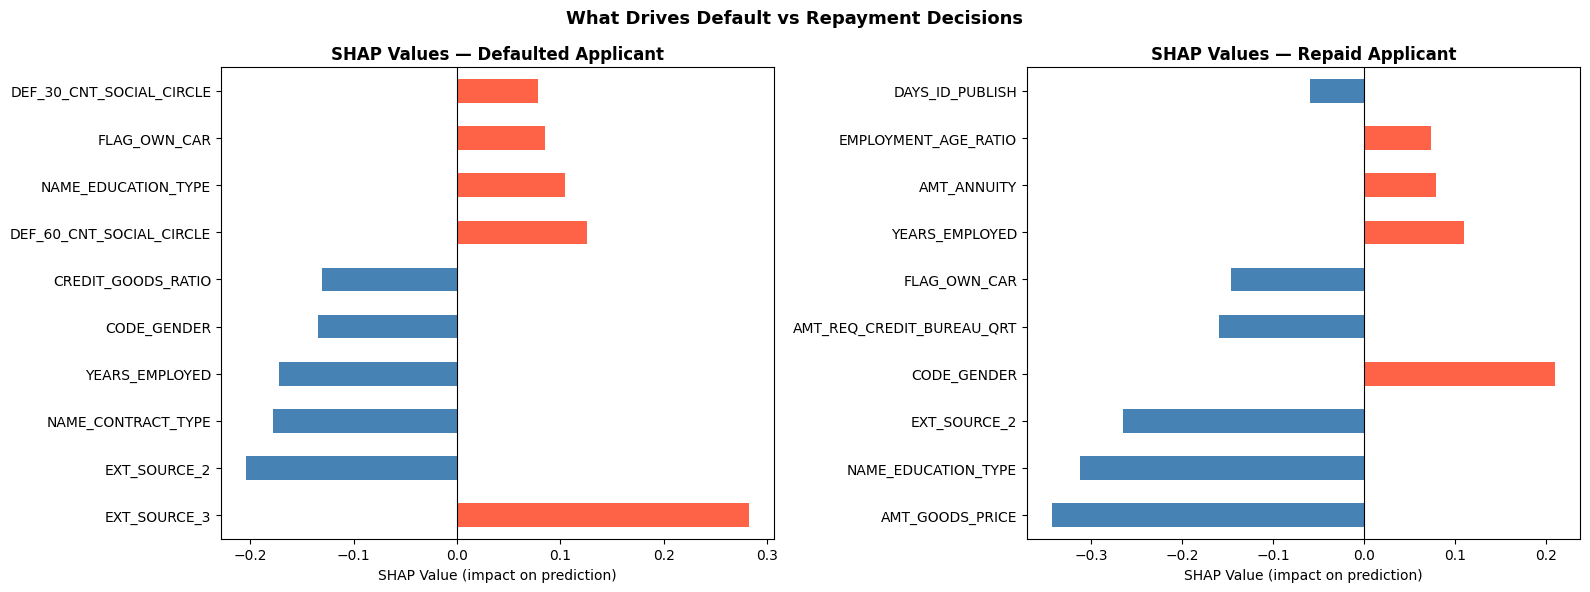

In [9]:
# Compare explanations side by side
# Shows what drives default vs repayment decisions

repayer_idx  = y_test[y_test == 0].index[0]
repayer_pos  = X_test.index.get_loc(repayer_idx)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top features pushing toward default for each applicant
for ax, pos, label, color in zip(
    axes,
    [position, repayer_pos],
    ['Defaulted Applicant', 'Repaid Applicant'],
    ['tomato', 'steelblue']
):
    shap_series = pd.Series(
        shap_values[pos],
        index=X_test.columns
    ).sort_values(key=abs, ascending=False).head(10)

    shap_series.plot(kind='barh', ax=ax, color=[
        'tomato' if v > 0 else 'steelblue'
        for v in shap_series.values
    ])
    ax.set_title(f"SHAP Values — {label}", fontweight='bold')
    ax.set_xlabel("SHAP Value (impact on prediction)")
    ax.axvline(0, color='black', linewidth=0.8)

plt.suptitle("What Drives Default vs Repayment Decisions",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_comparison.png',
            bbox_inches='tight', dpi=150)
plt.show()

In [10]:
# Get top 5 most impactful features globally
mean_shap    = np.abs(shap_values).mean(axis=0)
top_features = pd.Series(mean_shap, index=X_test.columns)
top_features = top_features.sort_values(ascending=False).head(5)

print("=" * 55)
print("     SHAP BUSINESS INTERPRETATION")
print("=" * 55)
print("\nTop 5 factors driving loan default risk:\n")

interpretations = {
    'EXT_SOURCE_3'         : 'External credit score — lower score = higher risk',
    'EXT_SOURCE_2'         : 'Secondary credit score — key repayment indicator',
    'EXT_SOURCE_1'         : 'Third-party risk score — validates creditworthiness',
    'CREDIT_INCOME_RATIO'  : 'Higher loan relative to income = more strain',
    'ANNUITY_INCOME_RATIO' : 'Higher monthly payment burden = default risk',
    'AGE_YEARS'            : 'Younger applicants tend to have higher default rates',
    'DAYS_EMPLOYED'        : 'Shorter employment history = less stability',
    'YEARS_EMPLOYED'       : 'Fewer years employed = higher risk',
    'AMT_CREDIT'           : 'Higher credit amount = higher exposure',
    'AMT_INCOME_TOTAL'     : 'Lower income = reduced repayment capacity'
}

for i, (feature, shap_score) in enumerate(top_features.items(), 1):
    meaning = interpretations.get(feature, 'Impacts default probability')
    print(f"  {i}. {feature}")
    print(f"     Mean SHAP : {shap_score:.4f}")
    print(f"     Meaning   : {meaning}")
    print()

print("=" * 55)
print("\nThis is what makes your model RBI-compliant:")
print("Every prediction can be explained in plain English.")
print("=" * 55)

     SHAP BUSINESS INTERPRETATION

Top 5 factors driving loan default risk:

  1. EXT_SOURCE_3
     Mean SHAP : 0.3919
     Meaning   : External credit score — lower score = higher risk

  2. EXT_SOURCE_2
     Mean SHAP : 0.3678
     Meaning   : Secondary credit score — key repayment indicator

  3. CODE_GENDER
     Mean SHAP : 0.1494
     Meaning   : Impacts default probability

  4. CREDIT_GOODS_RATIO
     Mean SHAP : 0.1386
     Meaning   : Impacts default probability

  5. NAME_EDUCATION_TYPE
     Mean SHAP : 0.1247
     Meaning   : Impacts default probability


This is what makes your model RBI-compliant:
Every prediction can be explained in plain English.


In [11]:
# Save SHAP values for use in Streamlit app
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_df.to_csv('../data/shap_values.csv', index=False)

print("SHAP values saved to ../data/shap_values.csv")
print("\nPhase 5 Complete. All SHAP plots saved to data/ folder.")

print("\nFiles generated:")
files = [
    'shap_summary_plot.png',
    'shap_bar_plot.png',
    'shap_dependence_plot.png',
    'shap_waterfall_defaulter.png',
    'shap_force_plot.png',
    'shap_comparison.png',
    'shap_values.csv'
]
for f in files:
    print(f"  ../data/{f}")

SHAP values saved to ../data/shap_values.csv

Phase 5 Complete. All SHAP plots saved to data/ folder.

Files generated:
  ../data/shap_summary_plot.png
  ../data/shap_bar_plot.png
  ../data/shap_dependence_plot.png
  ../data/shap_waterfall_defaulter.png
  ../data/shap_force_plot.png
  ../data/shap_comparison.png
  ../data/shap_values.csv
